In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/ayaanaraza/eyetracking/Images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS176_03.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS110_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS085_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS064_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS008_20.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS188_05.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS088_18.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS170_24.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS066_19.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS070_18.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS007_20.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS173_24.png
/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages/TS054_11.png
/kaggle/input/datasets/ay

In [ ]:

import os
import glob
import numpy as np
import cv2
#from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.decomposition import PCA

##AUGMENTATION

In [3]:
img_dim = 100
aug_img_count = 3
cropped_dir_tc= '/kaggle/working/Dataset/TC/Cropped'
cropped_dir_ts = '/kaggle/working/Dataset/TS/Cropped'
aug_tc_dir = '/kaggle/working/Dataset/TC/Augmented'
aug_ts_dir = '/kaggle/working/Dataset/TS/Augmented'
output_npz = '/kaggle/working/ASD_combined.npz'
os.makedirs(cropped_dir_tc, exist_ok=True)
os.makedirs(cropped_dir_ts, exist_ok=True)
os.makedirs(aug_tc_dir, exist_ok=True)
os.makedirs(aug_ts_dir, exist_ok=True)

Starting full dataset augmentation...

 Category: TC | Original images: 328
 Augmented 984 images saved to: /kaggle/working/Dataset/TC/Augmented

 Category: TS | Original images: 219
 Augmented 657 images saved to: /kaggle/working/Dataset/TS/Augmented

 Displaying 1 original + 2 augmented samples per category...


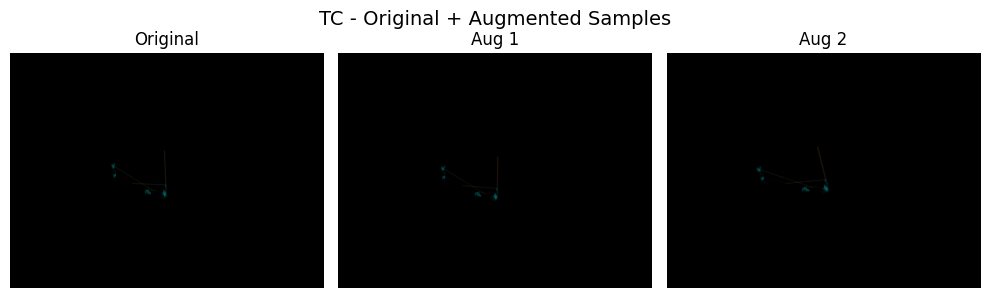

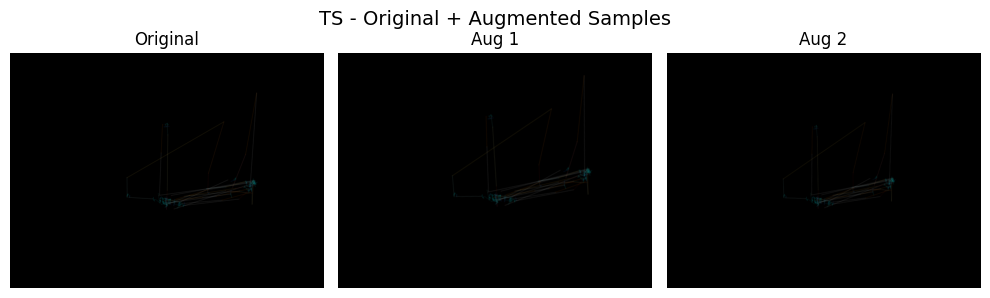

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# ============ STEP 1: IMAGE AUGMENTATION ============
print("Starting full dataset augmentation...")

# Setup augmenter
augmenter = ImageDataGenerator(rotation_range=10, shear_range=0.2, zoom_range=0.2, fill_mode='nearest')

# Define original and augmented image directories
categories = {
    'TC': '/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TCImages',
    'TS': '/kaggle/input/datasets/ayaanaraza/eyetracking/Images/TSImages'
}


# Update with your actual output folders for augmented images
aug_tc_dir = '/kaggle/working/Dataset/TC/Augmented'
aug_ts_dir = '/kaggle/working/Dataset/TS/Augmented'
os.makedirs(aug_tc_dir, exist_ok=True)
os.makedirs(aug_ts_dir, exist_ok=True)

# Number of augmented images to generate per original image
aug_img_count = 3

# Augment and save for all images
for category, folder in categories.items():
    save_dir = aug_tc_dir if category == 'TC' else aug_ts_dir
    image_paths = glob.glob(os.path.join(folder, '*.png'))
    print(f"\n Category: {category} | Original images: {len(image_paths)}")

    for file in image_paths:
        img = load_img(file)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        base_name = os.path.splitext(os.path.basename(file))[0]
        count = 0
        for batch in augmenter.flow(img_array, batch_size=1, save_to_dir=save_dir,
                                   save_prefix=base_name + '_aug', save_format='png'):
            count += 1
            # Save the augmented images with the number appended
            if count == aug_img_count:
                break

    print(f" Augmented {aug_img_count * len(image_paths)} images saved to: {save_dir}")

# ============ STEP 2: SHOW ONE ORIGINAL + TWO AUGMENTED SAMPLES ============
print("\n Displaying 1 original + 2 augmented samples per category...")

preview_aug_count = 2  # Number of augmentations to preview

for category, folder in categories.items():
    image_paths = glob.glob(os.path.join(categories[category], '*.png'))
    if not image_paths:
        continue

    # Pick the first image
    img_path = image_paths[0]
    img = load_img(img_path)
    img_array = img_to_array(img).astype('uint8')
    img_array = img_array.reshape((1,) + img_array.shape)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, preview_aug_count + 1, 1)
    plt.imshow(img_array[0].astype('uint8') / 255.0)
    plt.title("Original")
    plt.axis("off")

    for i, batch in enumerate(augmenter.flow(img_array, batch_size=1)):
        aug_img = batch[0].astype('uint8')
        # Add the augmentation number to the title
        plt.subplot(1, preview_aug_count + 1, i + 2)
        plt.imshow(aug_img / 255.0)
        plt.title(f'Aug {i+1}')
        plt.axis('off')
        if i + 1 == preview_aug_count:
            break

    plt.suptitle(f"{category} - Original + Augmented Samples", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.png')
aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.png')
print(f"TC Augmented: {len(aug_tc_images)} | TS: {len(aug_ts_images)}")

TC Augmented: 984 | TS: 657


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.[Pp][Nn][Gg]')
aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.[Pp][Nn][Gg]')
print(f"TC Augmented: {len(aug_tc_images)} | TS: {len(aug_ts_images)}")

print("First 5 TC Augmented Images:", aug_tc_images[:5])
print("First 5 TS Augmented Images:", aug_ts_images[:5])


TC Augmented: 984 | TS: 657
First 5 TC Augmented Images: ['/kaggle/working/Dataset/TC/Augmented/TC003_37_aug_0_5584.png', '/kaggle/working/Dataset/TC/Augmented/TC320_44_aug_0_8958.png', '/kaggle/working/Dataset/TC/Augmented/TC070_48_aug_0_3861.png', '/kaggle/working/Dataset/TC/Augmented/TC123_30_aug_0_636.png', '/kaggle/working/Dataset/TC/Augmented/TC078_52_aug_0_8770.png']
First 5 TS Augmented Images: ['/kaggle/working/Dataset/TS/Augmented/TS149_10_aug_0_2066.png', '/kaggle/working/Dataset/TS/Augmented/TS073_07_aug_0_791.png', '/kaggle/working/Dataset/TS/Augmented/TS212_08_aug_0_3946.png', '/kaggle/working/Dataset/TS/Augmented/TS170_24_aug_0_2689.png', '/kaggle/working/Dataset/TS/Augmented/TS070_18_aug_0_3224.png']


 Cropping augmented images and previewing...


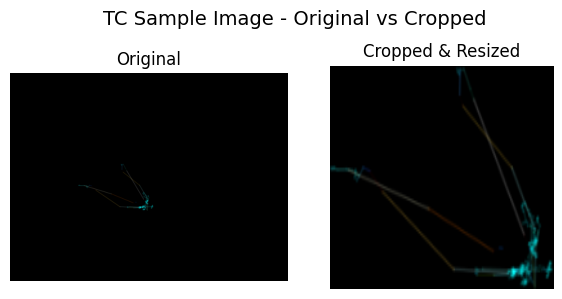

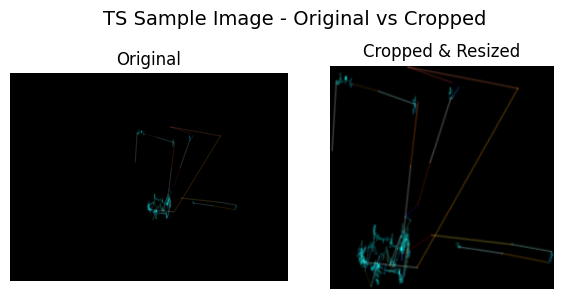


 Total Cropped Images:
   TC: 984
   TS: 657


In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

print(" Cropping augmented images and previewing...")

# Input folders
augmented_folders = [
    '/kaggle/working/Dataset/TC/Augmented',
    '/kaggle/working/Dataset/TS/Augmented'
]

# Output folders
cropped_dir_tc = '/kaggle/working/Dataset/TC/Cropped'
cropped_dir_ts = '/kaggle/working/Dataset/TS/Cropped'
os.makedirs(cropped_dir_tc, exist_ok=True)
os.makedirs(cropped_dir_ts, exist_ok=True)

# Counters and preview flags
tc_count = 0
ts_count = 0
tc_preview_shown = False
ts_preview_shown = False

# Process images
for folder in augmented_folders:
    for img_file in glob.iglob(os.path.join(folder, '**/*.png'), recursive=True):
        img = cv2.imread(img_file)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, threshed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(threshed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            cnt = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(cnt)
            cropped = img[y:y + h, x:x + w]
            resized = cv2.resize(cropped, (224, 224))

            # Decide category
            if 'TC' in folder:
                target_dir = cropped_dir_tc
                tc_count += 1
                preview_flag = not tc_preview_shown
                tc_preview_shown = True
            else:
                target_dir = cropped_dir_ts
                ts_count += 1
                preview_flag = not ts_preview_shown
                ts_preview_shown = True

            # Save
            img_id = os.path.basename(img_file).rsplit('.', 1)[0]
            save_path = os.path.join(target_dir, img_id + '.jpg')
            cv2.imwrite(save_path, resized, [int(cv2.IMWRITE_JPEG_QUALITY), 100])

            # Show one preview image per category
            if preview_flag:
                plt.figure(figsize=(6, 3))
                plt.subplot(1, 2, 1)
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title("Original")
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
                plt.title("Cropped & Resized")
                plt.axis("off")

                cat = 'TC' if 'TC' in folder else 'TS'
                plt.suptitle(f"{cat} Sample Image - Original vs Cropped", fontsize=14)
                plt.tight_layout()
                plt.show()

# Print final counts
print(f"\n Total Cropped Images:")
print(f"   TC: {tc_count}")
print(f"   TS: {ts_count}")


In [ ]:
aug_tc_images = glob.glob('/kaggle/working/Dataset/TC/Augmented/*.png')
crop_tc_images = glob.glob('/kaggle/working/Dataset/TC/Cropped/*.jpg')

print(f"TC Augmented: {len(aug_tc_images)} | TC Cropped: {len(crop_tc_images)}")

aug_ts_images = glob.glob('/kaggle/working/Dataset/TS/Augmented/*.png')
crop_ts_images = glob.glob('/kaggle/working/Dataset/TS/Cropped/*.jpg')

print(f"TC Augmented: {len(aug_ts_images)} | TC Cropped: {len(crop_ts_images)}")

TC Augmented: 984 | TC Cropped: 984
TC Augmented: 657 | TC Cropped: 657


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/working'):
    if filenames:  # Only print folders that contain files
        print(dirname)

/kaggle/working/Dataset/TC/Cropped
/kaggle/working/Dataset/TC/Augmented
/kaggle/working/Dataset/TS/Cropped
/kaggle/working/Dataset/TS/Augmented


## ResNet


In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, AveragePooling2D,MaxPooling2D
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score
#from scipy import interp
import matplotlib.pyplot as plt
import time

##BASE RESNET

In [ ]:
import os
import glob
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Feature Extraction with ResNet50
print(" Starting feature extraction using ResNet50...")

# ResNet50 model setup
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Directories
cropped_dirs = {
    'TC': '/kaggle/working/Dataset/TC/Cropped',
    'TS': '/kaggle/working/Dataset/TS/Cropped'
}

features = []
labels = []

# Extract features from each image
for label, (cat, folder) in enumerate(cropped_dirs.items()):
    print(f" Extracting features for category: {cat}")
    image_paths = glob.glob(os.path.join(folder, '*.jpg'))

    for img_path in tqdm(image_paths):
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        feature_vector = feature_extractor.predict(img_array, verbose=0)[0]
        features.append(feature_vector)
        labels.append(label)

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)
print(f" Feature extraction complete! X shape: {X.shape}, y shape: {y.shape}")

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)





 Starting feature extraction using ResNet50...


I0000 00:00:1745066115.934289      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
 Extracting features for category: TC


  0%|          | 0/984 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1745066124.535443      96 service.cc:148] XLA service 0x7e0f300015e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745066124.536743      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745066125.188811      96 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745066127.509748      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 984/984 [01:11<00:00, 13.81it/s]


 Extracting features for category: TS


100%|██████████| 657/657 [00:43<00:00, 15.23it/s]

 Feature extraction complete! X shape: (1641, 2048), y shape: (1641,)



 Applying PCA to retain 98% variance...
Original shape: (1641, 2048)
Reduced shape: (1641, 409)
Number of features selected: 409


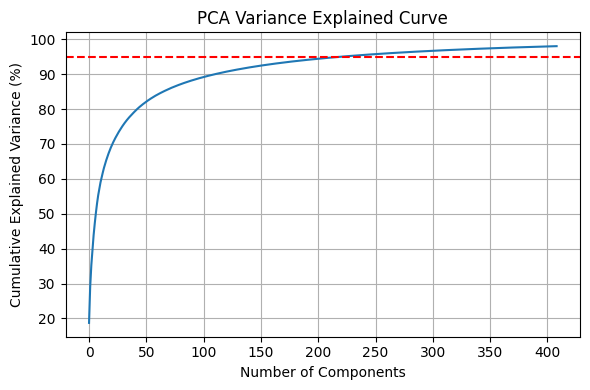

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Use PCA to retain 99% of the variance
print("\n Applying PCA to retain 98% variance...")

pca = PCA(n_components=0.98, random_state=42)
X_reduced = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
print(f"Number of features selected: {X_reduced.shape[1]}")

# Step 2 (optional): Plot cumulative explained variance
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Variance Explained Curve')
plt.grid(True)
plt.axhline(y=95, color='r', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



##Without PCA DNN


 Building and training classification model...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6444 - loss: 0.6849 - val_accuracy: 0.7143 - val_loss: 0.5147
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7484 - loss: 0.5117 - val_accuracy: 0.7416 - val_loss: 0.4998
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - loss: 0.4412 - val_accuracy: 0.7660 - val_loss: 0.4799
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7733 - loss: 0.4632 - val_accuracy: 0.8146 - val_loss: 0.4287
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8398 - loss: 0.3649 - val_accuracy: 0.7568 - val_loss: 0.4469
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8286 - loss: 0.3680 - val_accuracy: 0.7933 - val_loss: 0.4419
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8344 - loss: 0.3479 - val_accuracy: 0.8389 - val_loss: 0.3584
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8737 - loss: 0.2656 - val_accuracy: 0.8359 - val_loss: 0.

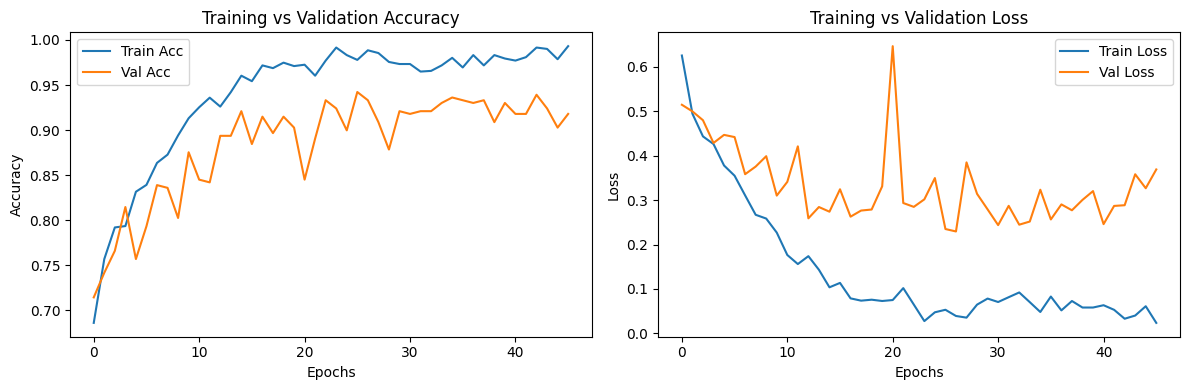


 Classification Report:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

          TC    0.93627   0.96954   0.95262       197
          TS    0.95200   0.90152   0.92607       132

    accuracy                        0.94225       329
   macro avg    0.94414   0.93553   0.93934       329
weighted avg    0.94258   0.94225   0.94197       329



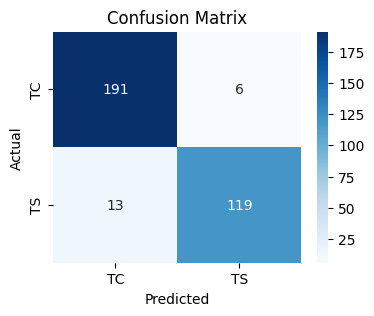

In [ ]:
# Step 3: Build and Train the Classification Model
print("\n Building and training classification model...")

classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification: TC (0) vs TS (1)
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Step 4: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluation
print("\n Classification Report:")
y_pred = (classifier.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


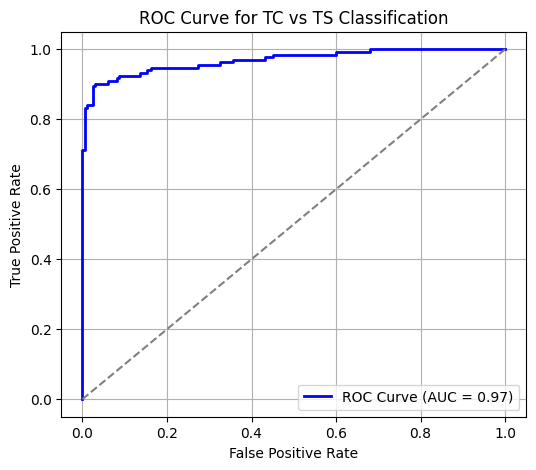

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities (not hard labels)
y_pred_probs = classifier.predict(X_test)

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TC vs TS Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



 Building and training classification model with reduced features...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6231 - loss: 0.6476 - val_accuracy: 0.7690 - val_loss: 0.4595
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.3784 - val_accuracy: 0.8267 - val_loss: 0.3771
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8935 - loss: 0.2729 - val_accuracy: 0.8967 - val_loss: 0.2929
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9349 - loss: 0.1807 - val_accuracy: 0.9149 - val_loss: 0.2393
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.0991 - val_accuracy: 0.9331 - val_loss: 0.2249
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0618 - val_accuracy: 0.9362 - val_loss: 0.1979
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9917 - loss: 0.0408 - val_accuracy: 0.9453 - val_loss: 0.2056
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9955 - loss: 0.0292 - val_accuracy: 0.9453 - val_loss: 0.

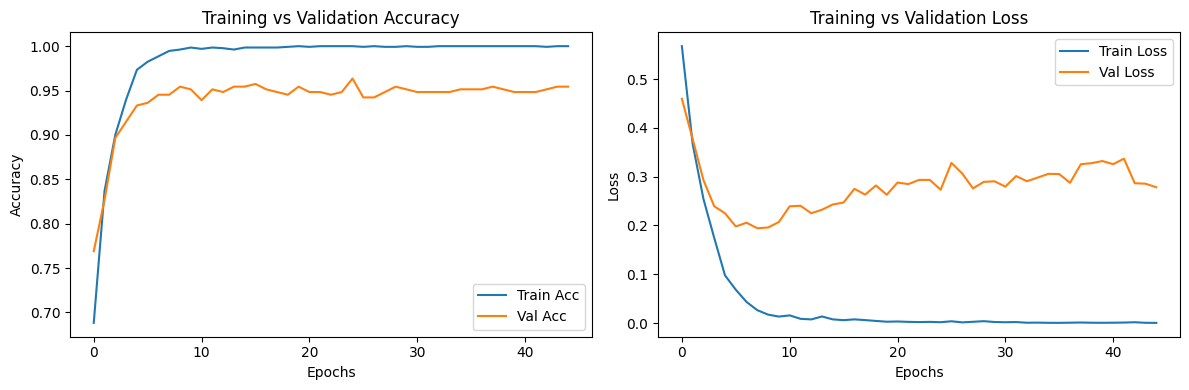


 Classification Report:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

          TC    0.95567   0.98477   0.97000       197
          TS    0.97619   0.93182   0.95349       132

    accuracy                        0.96353       329
   macro avg    0.96593   0.95829   0.96174       329
weighted avg    0.96390   0.96353   0.96338       329



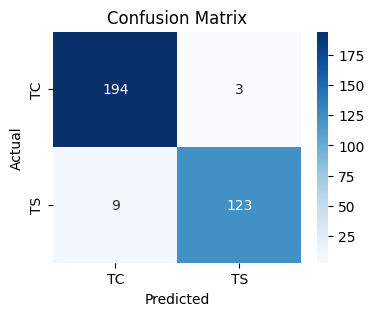

In [ ]:
# Step 3: Build and Train the Classification Model
print("\n Building and training classification model with reduced features...")
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)
classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X_reduced.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # For binary classification: TC (0) vs TS (1)
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Step 4: Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5: Evaluation
print("\n Classification Report:")
y_pred = (classifier.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


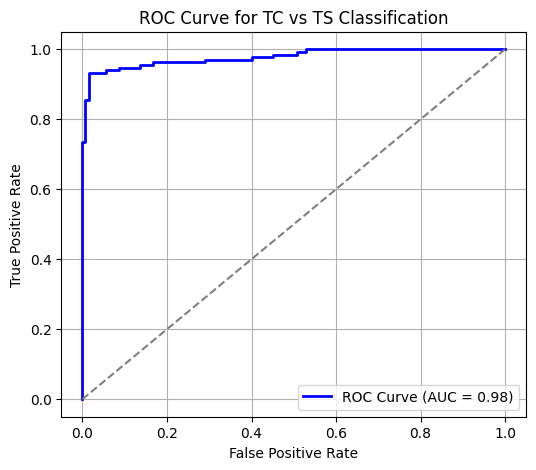

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities (not hard labels)
y_pred_probs = classifier.predict(X_test)

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for TC vs TS Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## ML with PCA

> Add blockquote




 Model: Random Forest
Accuracy: 0.8176
ROC AUC: 0.9352
Classification Report:
              precision    recall  f1-score   support

          TC       0.77      0.98      0.87       197
          TS       0.96      0.57      0.71       132

    accuracy                           0.82       329
   macro avg       0.87      0.78      0.79       329
weighted avg       0.85      0.82      0.81       329


 Model: Extra Trees
Accuracy: 0.8419
ROC AUC: 0.9519
Classification Report:
              precision    recall  f1-score   support

          TC       0.79      0.99      0.88       197
          TS       0.99      0.61      0.76       132

    accuracy                           0.84       329
   macro avg       0.89      0.80      0.82       329
weighted avg       0.87      0.84      0.83       329


 Model: AdaBoost
Accuracy: 0.7964
ROC AUC: 0.8381
Classification Report:
              precision    recall  f1-score   support

          TC       0.81      0.86      0.83       197
       

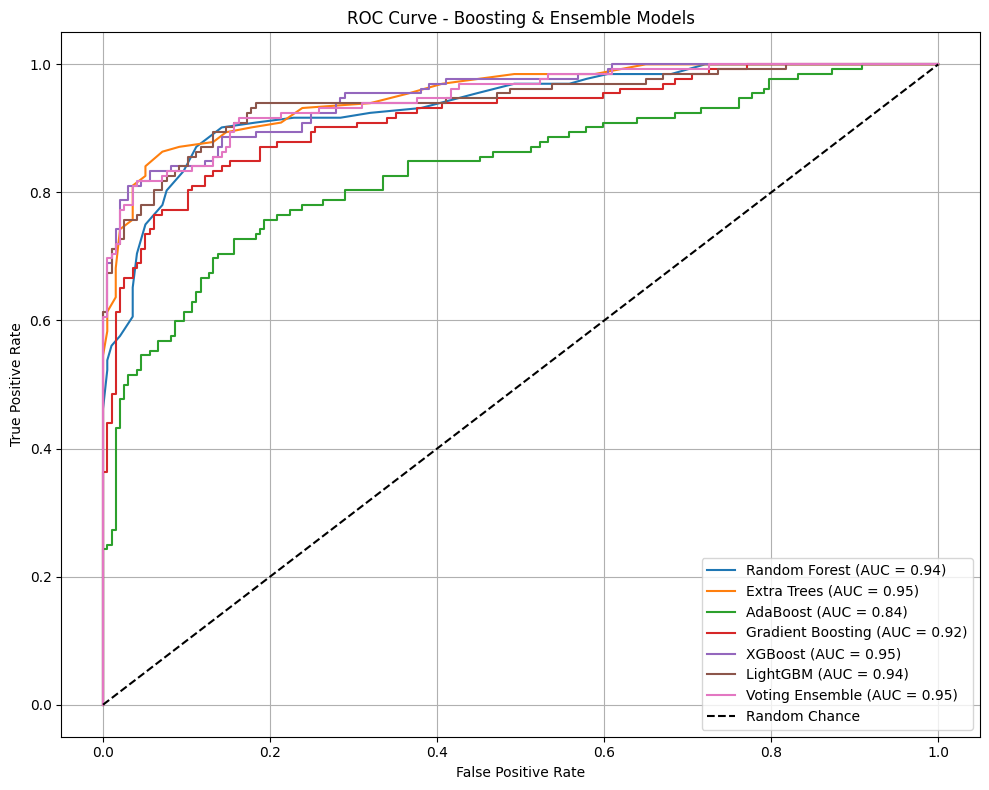

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# === ASSUME features and labels already loaded as X_features, y_labels ===

# Train/test split
#X_train, X_test, y_train, y_test = train_test_split(X_pca, y_labels, test_size=0.2, random_state=42)

# === MODELS ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Add a Voting Classifier (Ensemble)
models["Voting Ensemble"] = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('gb', models["Gradient Boosting"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

# === EVALUATION ===
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["TC", "TS"])
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Print performance
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("Classification Report:")
    print(report)

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# === ROC Curve Final Plot ===
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Boosting & Ensemble Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


## ML without PCA


 Model: Random Forest
Accuracy: 0.8571
ROC AUC: 0.9232
Classification Report:
              precision    recall  f1-score   support

          TC       0.83      0.96      0.89       197
          TS       0.93      0.70      0.80       132

    accuracy                           0.86       329
   macro avg       0.88      0.83      0.84       329
weighted avg       0.87      0.86      0.85       329


 Model: Extra Trees
Accuracy: 0.8693
ROC AUC: 0.9521
Classification Report:
              precision    recall  f1-score   support

          TC       0.83      0.97      0.90       197
          TS       0.95      0.71      0.81       132

    accuracy                           0.87       329
   macro avg       0.89      0.84      0.86       329
weighted avg       0.88      0.87      0.87       329


 Model: AdaBoost
Accuracy: 0.8024
ROC AUC: 0.8767
Classification Report:
              precision    recall  f1-score   support

          TC       0.81      0.87      0.84       197
       

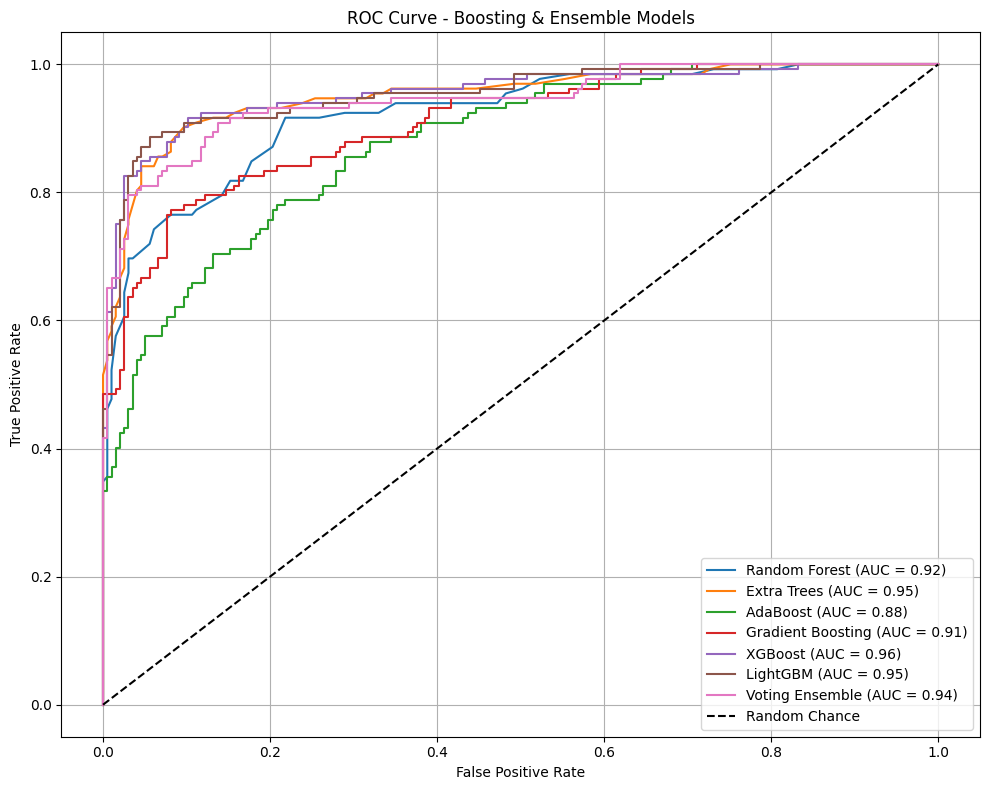

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === MODELS ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Add a Voting Classifier (Ensemble)
models["Voting Ensemble"] = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('gb', models["Gradient Boosting"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

# === EVALUATION ===
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["TC", "TS"])
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Print performance
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("Classification Report:")
    print(report)

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# === ROC Curve Final Plot ===
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Boosting & Ensemble Models')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


## ResNet Direct

In [ ]:
import os, glob, numpy as np, cv2
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


In [ ]:
def load_images(folder, label):
    images, labels = [], []
    for path in glob.glob(os.path.join(folder, '*.jpg')):
        img = load_img(path, target_size=(224, 224))
        img = img_to_array(img)
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return images, labels

# Load from your cropped folders
tc_imgs, tc_labels = load_images('/kaggle/working/Dataset/TC/Cropped', 0)
ts_imgs, ts_labels = load_images('/kaggle/working/Dataset/TS/Cropped', 1)

X = np.array(tc_imgs + ts_imgs)
y = np.array(tc_labels + ts_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [ ]:
# Load ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # Enable fine-tuning

# Add classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=100, batch_size=32, callbacks=[early_stop])


Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 76s 326ms/step - accuracy: 0.5994 - loss: 0.6948 - val_accuracy: 0.5988 - val_loss: 0.7840
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.8314 - loss: 0.4140 - val_accuracy: 0.6018 - val_loss: 0.7442
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.8702 - loss: 0.3204 - val_accuracy: 0.6231 - val_loss: 0.6682
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.9293 - loss: 0.2307 - val_accuracy: 0.7173 - val_loss: 0.5523
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.9548 - loss: 0.1792 - val_accuracy: 0.8085 - val_loss: 0.4611
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.9753 - loss: 0.1206 - val_accuracy: 0.8389 - val_loss: 0.3950
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.9941 - loss: 0.0760 - val_accuracy: 0.8875 - val_loss: 0.3457
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.9986 - loss: 0.0465 - val_acc

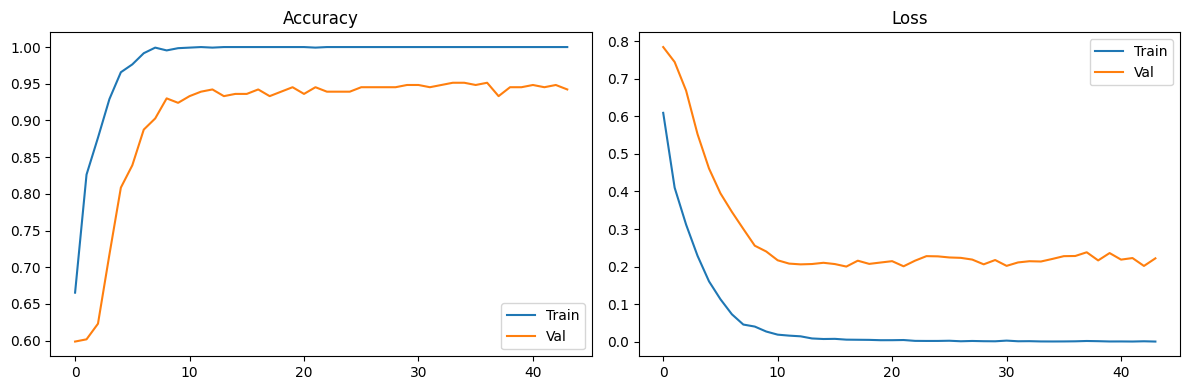

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 412ms/step
Classification Report:
               precision    recall  f1-score   support

          TC    0.93720   0.98477   0.96040       197
          TS    0.97541   0.90152   0.93701       132

    accuracy                        0.95137       329
   macro avg    0.95630   0.94314   0.94870       329
weighted avg    0.95253   0.95137   0.95101       329



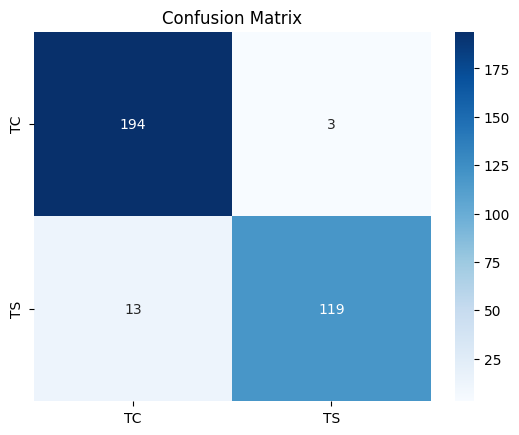

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend()
plt.tight_layout()
plt.show()

y_pred = (model.predict(X_test) > 0.5).astype('int32')
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


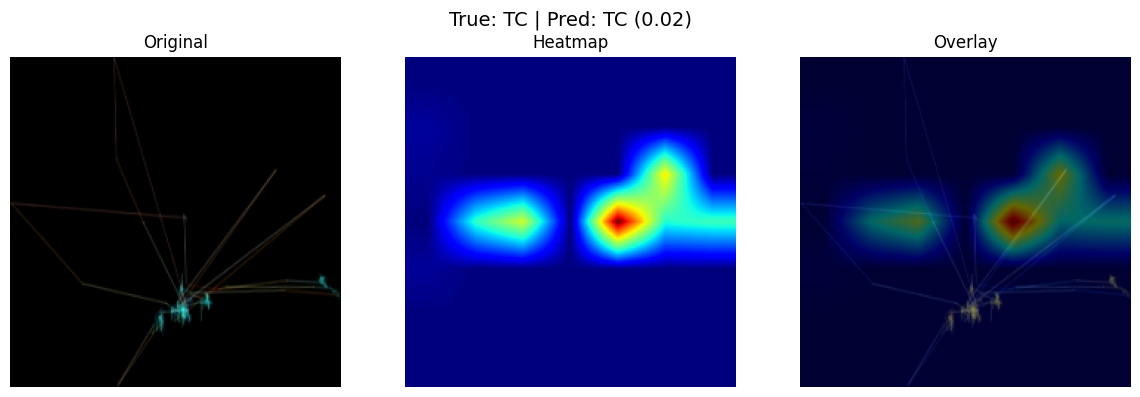

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


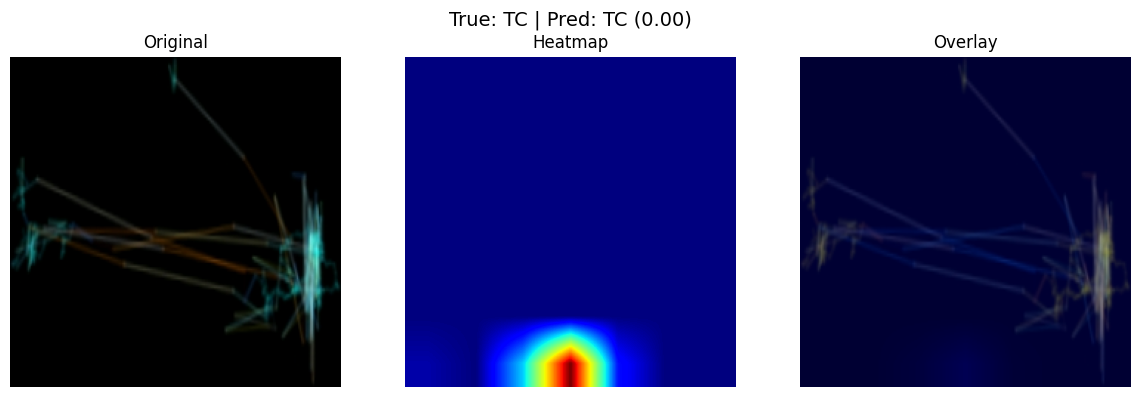

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


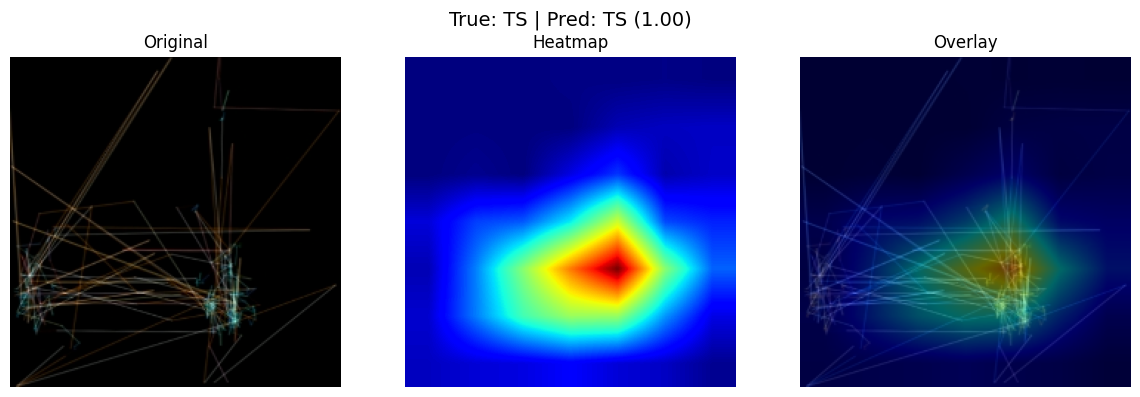

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


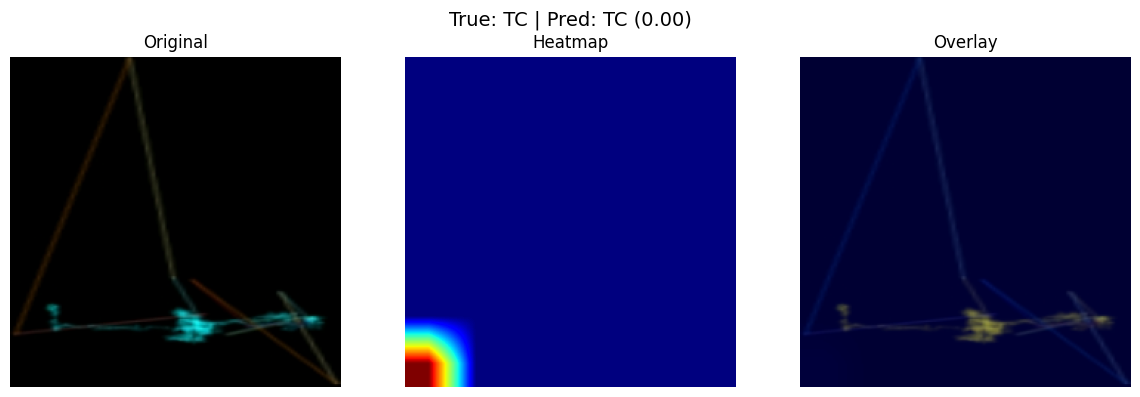

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


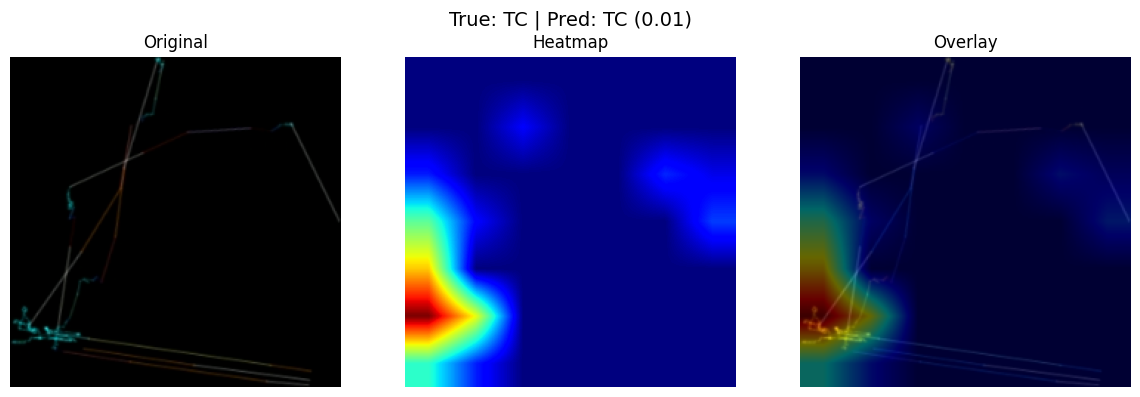

In [ ]:

import os, glob, numpy as np, cv2, random
def make_gradcam_heatmap(img_array, model, last_conv_layer='conv5_block3_out'):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer).output, model.output])
    with tf.GradientTape() as tape:
        conv_output, prediction = grad_model(img_array)
        loss = prediction[:, 0]
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0].numpy()
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]
    heatmap = np.mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

#  DISPLAY MULTIPLE GRAD-CAMs
def display_gradcam_batch(X_data, y_data, model, num_samples=5, last_conv_layer='conv5_block3_out'):
    indices = random.sample(range(len(X_data)), num_samples)
    for idx in indices:
        img = X_data[idx]
        label = y_data[idx]
        img_input = np.expand_dims(img, axis=0)
        heatmap = make_gradcam_heatmap(img_input, model, last_conv_layer)

        orig = (img + [103.939, 116.779, 123.68])[..., ::-1]  # BGR to RGB
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_vis = np.uint8(255 * heatmap_resized)
        overlay = cv2.applyColorMap(heatmap_vis, cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(np.uint8(orig), 0.6, overlay, 0.4, 0)

        pred = model.predict(img_input)[0][0]
        pred_class = 'TS' if pred >= 0.5 else 'TC'
        actual_class = 'TS' if label == 1 else 'TC'

        plt.figure(figsize=(12, 4))
        plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred:.2f})", fontsize=14)

        plt.subplot(1, 3, 1)
        plt.imshow(np.uint8(orig)); plt.title("Original"); plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='jet'); plt.title("Heatmap"); plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        plt.title("Overlay"); plt.axis('off')

        plt.tight_layout()
        plt.show()

# STEP 7: RUN VISUALIZATION
display_gradcam_batch(X_test, y_test, model, num_samples=5)


#PCA DNN

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization, SeparableConv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Load ResNet50 base (freeze lower layers to avoid overfitting on small data)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning the last layers
for layer in base_model.layers[:140]:
    layer.trainable = False
for layer in base_model.layers[140:]:
    layer.trainable = True

# Add custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

# Define model
model = Model(inputs=base_model.input, outputs=output)

# Use a learning rate schedule with exponential decay
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000,
    decay_rate=0.9
)

# Compile model with Adam optimizer
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping and model checkpoint to save best model
early_stop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
#checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

# Train with additional callback and smaller batch size
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,  # Smaller batch size for better generalization
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 144ms/step - accuracy: 0.6446 - loss: 0.7426 - val_accuracy: 0.7933 - val_loss: 0.4676
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.8693 - loss: 0.2970 - val_accuracy: 0.9119 - val_loss: 0.3004
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9621 - loss: 0.1218 - val_accuracy: 0.9392 - val_loss: 0.1875
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9732 - loss: 0.0875 - val_accuracy: 0.9696 - val_loss: 0.1347
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9815 - loss: 0.0563 - val_accuracy: 0.9453 - val_loss: 0.1283
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9827 - loss: 0.0569 - val_accuracy: 0.9422 - val_loss: 0.1647
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9810 - loss: 0.0636 - val_accuracy: 0.9483 - val_loss: 0.1921
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9797 - loss: 0.0542 - val_accuracy: 

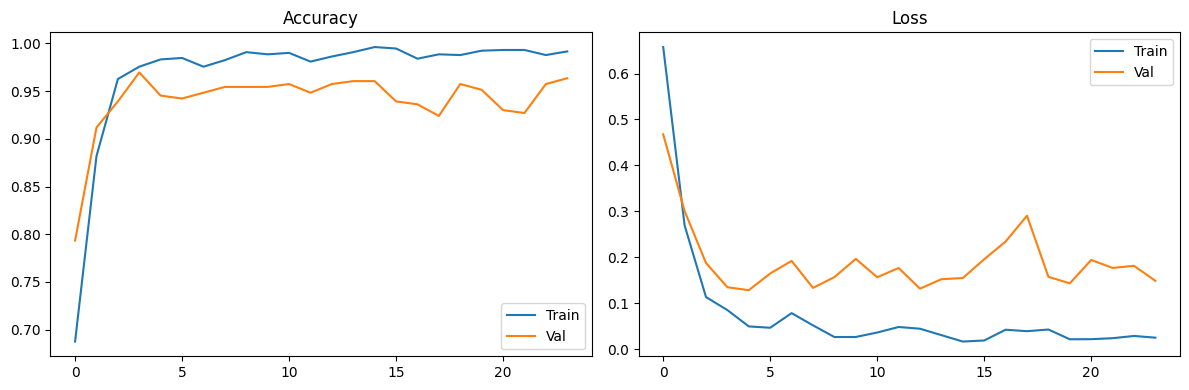

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 416ms/step
Classification Report:
               precision    recall  f1-score   support

          TC    0.96517   0.98477   0.97487       197
          TS    0.97656   0.94697   0.96154       132

    accuracy                        0.96960       329
   macro avg    0.97087   0.96587   0.96821       329
weighted avg    0.96974   0.96960   0.96952       329



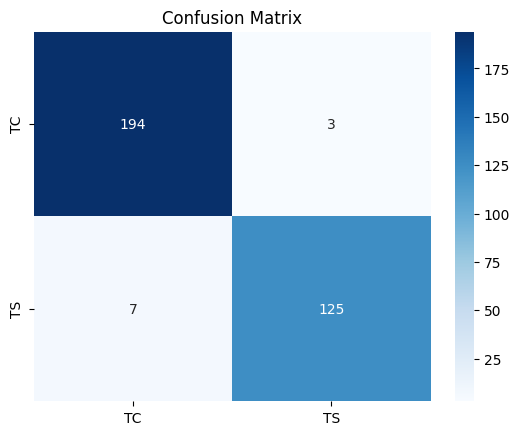

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend()
plt.tight_layout()
plt.show()

y_pred = (model.predict(X_test) > 0.5).astype('int32')
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['TC', 'TS'], digits=5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TC', 'TS'], yticklabels=['TC', 'TS'])
plt.title("Confusion Matrix")
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


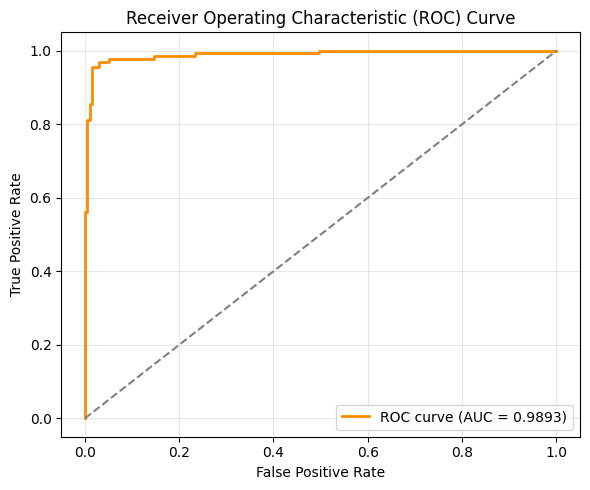

In [ ]:
# Get predicted probabilities
y_pred_prob = model.predict(X_test).ravel()

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


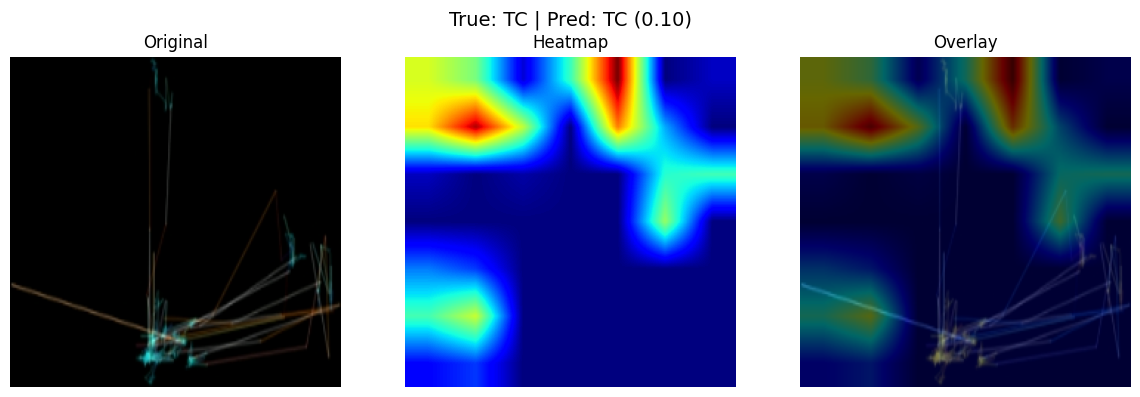

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


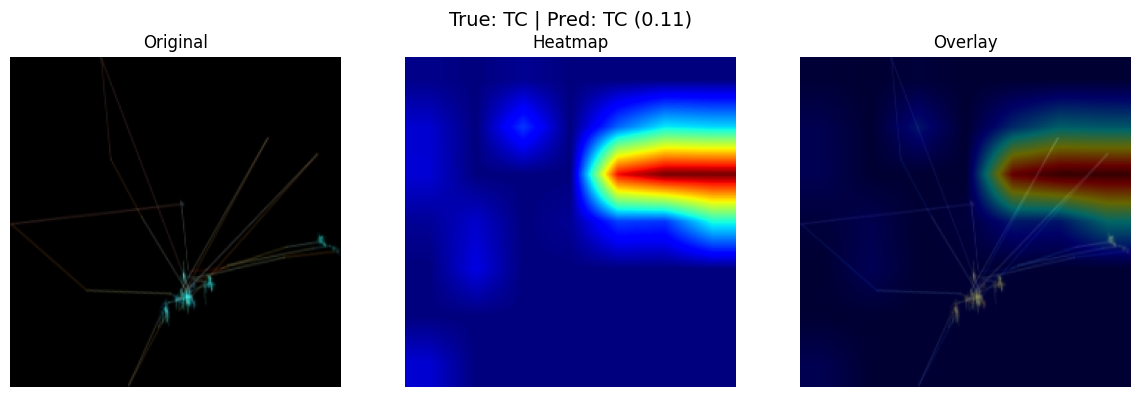

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


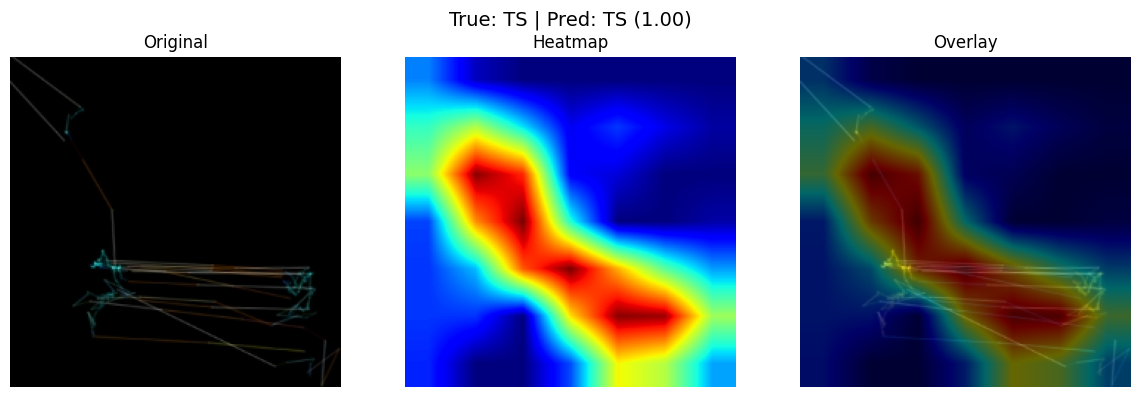

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


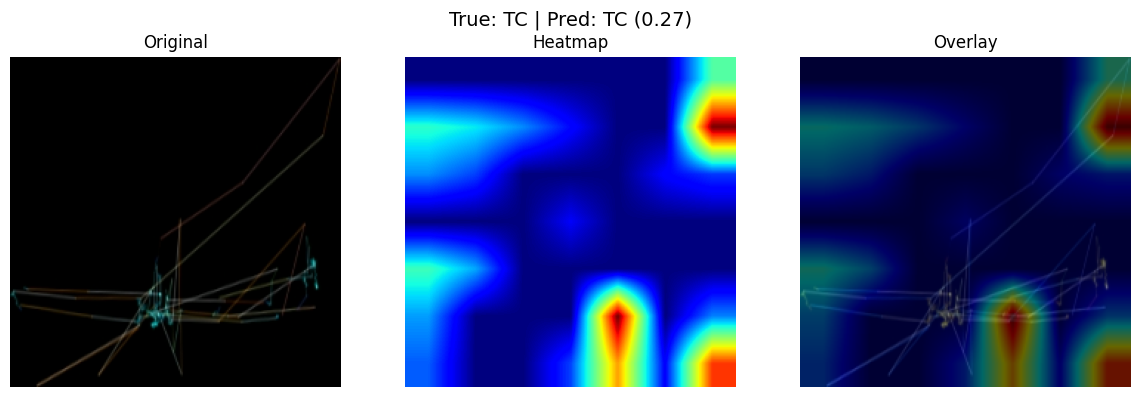

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


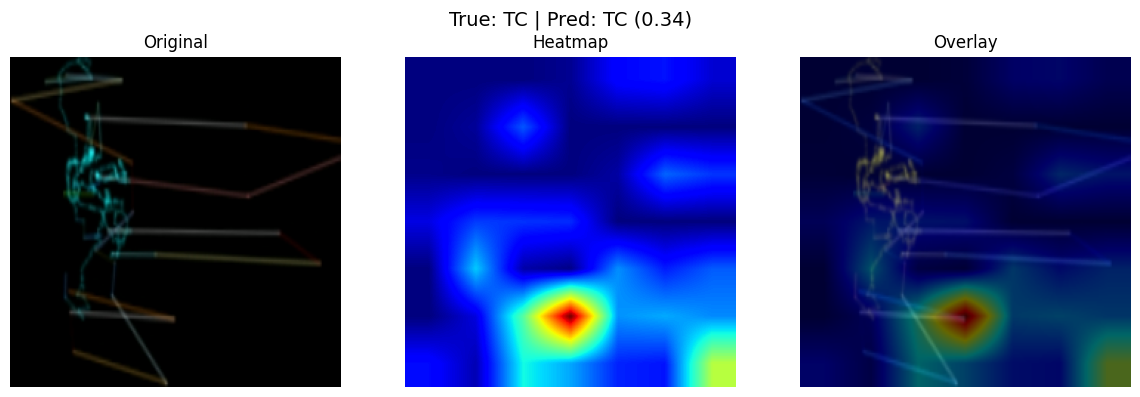

In [ ]:

import os, glob, numpy as np, cv2, random
def make_gradcam_heatmap(img_array, model, last_conv_layer='conv5_block3_out'):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer).output, model.output])
    with tf.GradientTape() as tape:
        conv_output, prediction = grad_model(img_array)
        loss = prediction[:, 0]
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0].numpy()
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]
    heatmap = np.mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

#  DISPLAY MULTIPLE GRAD-CAMs
def display_gradcam_batch(X_data, y_data, model, num_samples=5, last_conv_layer='conv5_block3_out'):
    indices = random.sample(range(len(X_data)), num_samples)
    for idx in indices:
        img = X_data[idx]
        label = y_data[idx]
        img_input = np.expand_dims(img, axis=0)
        heatmap = make_gradcam_heatmap(img_input, model, last_conv_layer)

        orig = (img + [103.939, 116.779, 123.68])[..., ::-1]  # BGR to RGB
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_vis = np.uint8(255 * heatmap_resized)
        overlay = cv2.applyColorMap(heatmap_vis, cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(np.uint8(orig), 0.6, overlay, 0.4, 0)

        pred = model.predict(img_input)[0][0]
        pred_class = 'TS' if pred >= 0.5 else 'TC'
        actual_class = 'TS' if label == 1 else 'TC'

        plt.figure(figsize=(12, 4))
        plt.suptitle(f"True: {actual_class} | Pred: {pred_class} ({pred:.2f})", fontsize=14)

        plt.subplot(1, 3, 1)
        plt.imshow(np.uint8(orig)); plt.title("Original"); plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='jet'); plt.title("Heatmap"); plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        plt.title("Overlay"); plt.axis('off')

        plt.tight_layout()
        plt.show()

#  RUN VISUALIZATION
display_gradcam_batch(X_test, y_test, model, num_samples=5)
